# Saccades — Model Replication

**Target figures from the saccade literature:**

| Section | Paper | Key finding |
|---------|-------|-------------|
| 1 | Bahill, Clark & Stark (1975) *Math Biosci* | Main sequence: peak velocity saturates as `v_peak = 700·(1−e^{−A/7})` |
| 2 | Bahill et al. (1975) / Hyde (1959) | Duration scales linearly with amplitude |
| 3 | Robinson (1975) *Basic Mechanisms of Ocular Motility* | Local feedback burst generator: e_held → burst → x_copy → closes to zero |
| 4 | Yarbus (1967) / Van Gisbergen et al. (1985) | Oblique saccades: H and V components synchronized, straight trajectory |

### Model parameters relevant to this notebook

- `g_burst` — burst gain (deg/s per deg error); sets peak velocity saturation
- `k_sac` — error scaling in burst nonlinearity; sets the amplitude at half-saturation
- `e_sat_sac` — saturation error; clips burst at large amplitudes
- `threshold_acc` — z_acc threshold to trigger a saccade (~0.5)
- `threshold_ref` — z_ref level below which z_acc can recharge (refractory gate)
- `alpha_reset` — z_ref decay rate; controls refractory period duration

In [11]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from oculomotor.sim.simulator import (
    PARAMS_DEFAULT, with_brain, simulate,
    _IDX_NI, _IDX_SG, _IDX_VIS,
)
from oculomotor.models.brain_models import saccade_generator as sg_mod
from oculomotor.models.sensory_models.sensory_model import C_pos, C_gate
from oculomotor import __version__

print(f'oculomotor {__version__}')

THETA = with_brain(PARAMS_DEFAULT, g_burst=700.0)
print(f'g_burst={THETA.brain.g_burst}  k_sac={THETA.brain.k_sac}  '
      f'e_sat_sac={THETA.brain.e_sat_sac}  tau_p={THETA.brain.tau_p} s')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 9

_C = {
    'target': '#d6604d',
    'eye':    '#2166ac',
    'ni':     '#4dac26',
    'error':  '#762a83',
    'burst':  '#f4a582',
    'vel':    '#1a9641',
    'ref':    '#aaaaaa',
    'acc':    '#e08214',
    'latch':  '#1b7837',
    'copy':   '#e08214',
}

oculomotor ef648fb-dirty
g_burst=700.0  k_sac=200.0  e_sat_sac=7.0  tau_p=0.15 s


In [12]:
# ── Shared analysis helpers ─────────────────────────────────────────────────────
from oculomotor.analysis import extract_burst, extract_sg, saccade_metrics, ax_fmt

# ── Notebook-local helpers ──────────────────────────────────────────────────────

def make_target(t_np, jumps, T):
    """Build (T,3) target position array from [(t_jump, yaw_deg, pitch_deg), ...]."""
    pt3 = np.zeros((T, 3)); pt3[:, 2] = 1.0
    yaw = np.zeros(T); pitch = np.zeros(T)
    for tj, y, p in jumps:
        yaw[t_np >= tj]   = y
        pitch[t_np >= tj] = p
    pt3[:, 0] = np.tan(np.radians(yaw))
    pt3[:, 1] = np.tan(np.radians(pitch))
    return jnp.array(pt3), yaw, pitch

ImportError: cannot import name '_IDX_VIS_L' from 'oculomotor.sim.simulator' (D:\OneDrive\UC Berkeley\OMlab - JOM\Code\ClaudeOculomotorJax\src\oculomotor\sim\simulator.py)

---
## 1. Main Sequence

### Bahill, Clark & Stark (1975) — *Mathematical Biosciences* 26:303–318

**Key figure:** Peak velocity vs amplitude scatter plot.

**Key findings:**
- Peak saccade velocity saturates with amplitude: `v_peak ≈ 700·(1−e^{−A/7})` (human values)
- Duration increases approximately linearly with amplitude: `D ≈ 2.2·A + 21 ms` (human)
- The relationship is stereotyped — saccades to the same amplitude have nearly identical kinematics

**Model parameters that control the main sequence:**
- `g_burst` → sets the asymptotic peak velocity (~700 deg/s)
- `k_sac` → sets the amplitude at which velocity reaches ~63% of saturation (~7°)
- `tau_p` → plant time constant; shapes the velocity profile

![alt text](images/Bahill_1975a.png)

In [ ]:
# ── Simulate saccades across a range of amplitudes ────────────────────────────
AMPLITUDES = np.array([0.5, 1, 2, 3, 5, 8, 10, 15, 20, 25, 30], dtype=float)
DT   = 0.001
TEND = 0.8
TJUMP = 0.1

t_ms    = jnp.arange(0.0, TEND, DT)
T_ms    = len(t_ms)
t_ms_np = np.array(t_ms)
jump_idx = int(TJUMP / DT)

amps_out, peak_vels, durations = [], [], []

print('Running main sequence simulations...')
for amp in AMPLITUDES:
    pt3 = jnp.stack([
        jnp.where(t_ms >= TJUMP, jnp.tan(jnp.radians(float(amp))), 0.0),
        jnp.zeros(T_ms),
        jnp.ones(T_ms),
    ], axis=1)
    eye = np.array(simulate(THETA, t_ms, p_target_array=pt3,
                            scene_present_array=jnp.ones(T_ms),
                            max_steps=int(TEND/DT)+200))
    vel = np.gradient(eye[:, 0], DT)
    a, v, d = saccade_metrics(eye[:, 0], vel, jump_idx, DT)
    amps_out.append(a); peak_vels.append(v); durations.append(d)

amps_out  = np.array(amps_out)
peak_vels = np.array(peak_vels)
durations = np.array(durations)
print('Done.')

# Fit main sequence curve: v = g * (1 - exp(-A/k))
try:
    popt, _ = curve_fit(lambda A, g, k: g*(1-np.exp(-A/k)),
                        amps_out, peak_vels, p0=[700, 7], maxfev=5000)
    g_fit, k_fit = popt
    print(f'  Main sequence fit: v = {g_fit:.0f}·(1−e^{{−A/{k_fit:.1f}}})'
          f'  (model: g_burst={THETA.brain.g_burst:.0f}, k_sac={THETA.brain.k_sac:.1f})')
except Exception as e:
    g_fit, k_fit = THETA.brain.g_burst, THETA.brain.k_sac
    print(f'  Fit failed: {e}')

Running main sequence simulations...
Done.
  Main sequence fit: v = 694·(1−e^{−A/12.9})  (model: g_burst=700, k_sac=200.0)


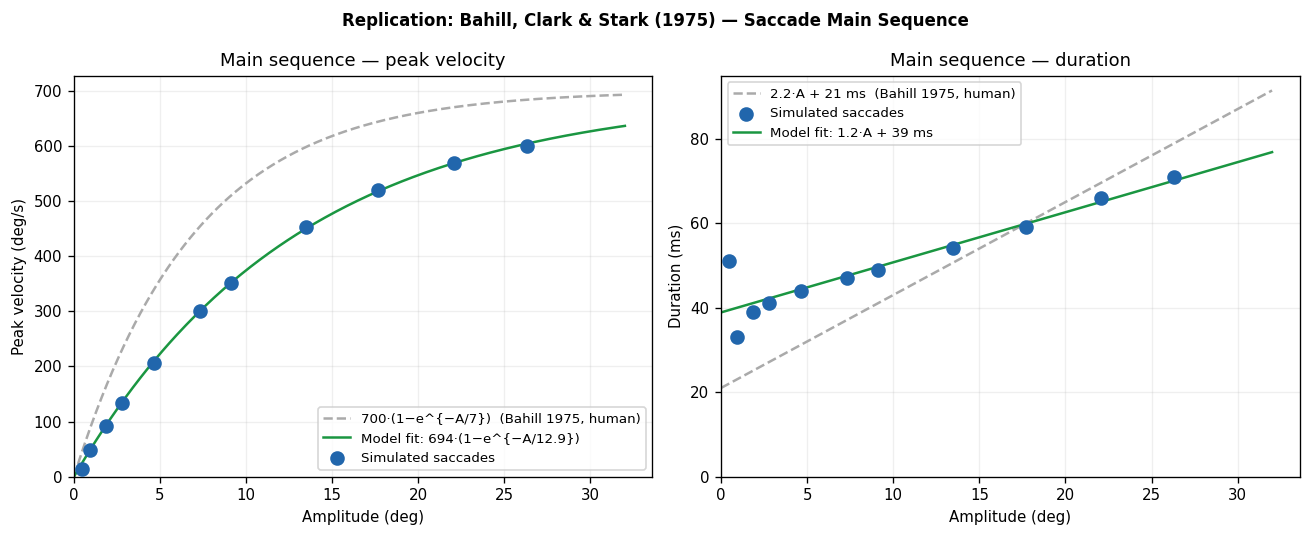

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Replication: Bahill, Clark & Stark (1975) — Saccade Main Sequence',
             fontsize=10, fontweight='bold')

A_ref = np.linspace(0, 32, 300)

# ── Peak velocity vs amplitude ────────────────────────────────────────────────
ax = axes[0]
ax.plot(A_ref, 700*(1-np.exp(-A_ref/7)),
        color=_C['ref'], lw=1.5, ls='--', label='700·(1−e^{−A/7})  (Bahill 1975, human)')
ax.plot(A_ref, g_fit*(1-np.exp(-A_ref/k_fit)),
        color=_C['vel'], lw=1.5, ls='-',
        label=f'Model fit: {g_fit:.0f}·(1−e^{{−A/{k_fit:.1f}}})')
ax.scatter(amps_out, peak_vels, color=_C['eye'], s=60, zorder=5, label='Simulated saccades')
ax.set_xlabel('Amplitude (deg)')
ax.set_ylabel('Peak velocity (deg/s)')
ax.set_title('Main sequence — peak velocity')
ax.set_xlim(0); ax.set_ylim(0)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ── Duration vs amplitude ─────────────────────────────────────────────────────
ax = axes[1]
# Human reference: D ≈ 2.2*A + 21 ms (Bahill 1975)
ax.plot(A_ref, 2.2*A_ref + 21,
        color=_C['ref'], lw=1.5, ls='--', label='2.2·A + 21 ms  (Bahill 1975, human)')
valid = ~np.isnan(durations)
ax.scatter(amps_out[valid], durations[valid], color=_C['eye'], s=60, zorder=5,
           label='Simulated saccades')
# Fit duration-amplitude
try:
    pd, _ = curve_fit(lambda A, m, b: m*A+b, amps_out[valid], durations[valid], p0=[2.2, 21])
    ax.plot(A_ref, pd[0]*A_ref+pd[1], color=_C['vel'], lw=1.5,
            label=f'Model fit: {pd[0]:.1f}·A + {pd[1]:.0f} ms')
except: pass
ax.set_xlabel('Amplitude (deg)')
ax.set_ylabel('Duration (ms)')
ax.set_title('Main sequence — duration')
ax.set_xlim(0); ax.set_ylim(0)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

fig.tight_layout()
plt.show()

### Comparison with Bahill et al. 1975

| Quantity | Bahill et al. 1975 (human) | Model (fit above) |
|----------|---------------------------|-------------------|
| Peak velocity asymptote | ~700 deg/s | |
| Half-saturation amplitude | ~7° | |
| Duration slope | ~2.2 ms/deg | |
| Duration intercept | ~21 ms | |

---
## 2. Saccade Signal Cascade — Robinson's Local Feedback

### Robinson (1975) — *Basic Mechanisms of Ocular Motility*

**Key concept:** The saccade generator uses a local feedback loop. The burst neuron fires in proportion to the *residual motor error* — the difference between the desired displacement (held at saccade onset) and the current eye displacement (tracked by an internal copy). When the copy catches up, the burst stops.

**Signal flow:**
```
Target step
  → visual delay cascade (~120 ms)  →  e_pos_delayed rises
  → z_acc accumulates  →  crosses threshold  →  z_sac latches
  → e_held freezes (sample-and-hold of the cascade output)
  → e_res = e_held − x_copy  drives burst
  → burst → NI + plant → eye moves
  → x_copy integrates burst  →  x_copy → e_held  →  e_res → 0
  → z_ref charges  →  z_sac releases  →  refractory period
```

> *Place Robinson (1975) local feedback diagram here.*

In [ ]:
# ── Single saccade cascade for three amplitudes ───────────────────────────────
CASCADE_AMPS = [5.0, 15.0, 30.0]
TEND_C = 0.8
TJUMP_C = 0.15
t_c    = jnp.arange(0.0, TEND_C, DT)
T_c    = len(t_c)
t_c_np = np.array(t_c)

cascade_data = {}
print('Running cascade simulations...')
for amp in CASCADE_AMPS:
    pt3, tgt_yaw, _ = make_target(t_c_np, [(TJUMP_C, amp, 0.0)], T_c)
    states = simulate(THETA, t_c, p_target_array=pt3,
                      scene_present_array=jnp.ones(T_c),
                      max_steps=int(TEND_C/DT)+200, return_states=True)
    sg = extract_sg(states, THETA)
    ep = np.array(states.plant)
    cascade_data[amp] = dict(
        tgt_yaw  = tgt_yaw,
        eye_pos  = ep[:, 0],
        eye_vel  = np.gradient(ep[:, 0], DT),
        **{k: v[:, 0] if v.ndim == 2 else v for k, v in sg.items()},
        u_burst_h = sg['u_burst'][:, 0],
    )
print('Done.')

Running cascade simulations...
Done.


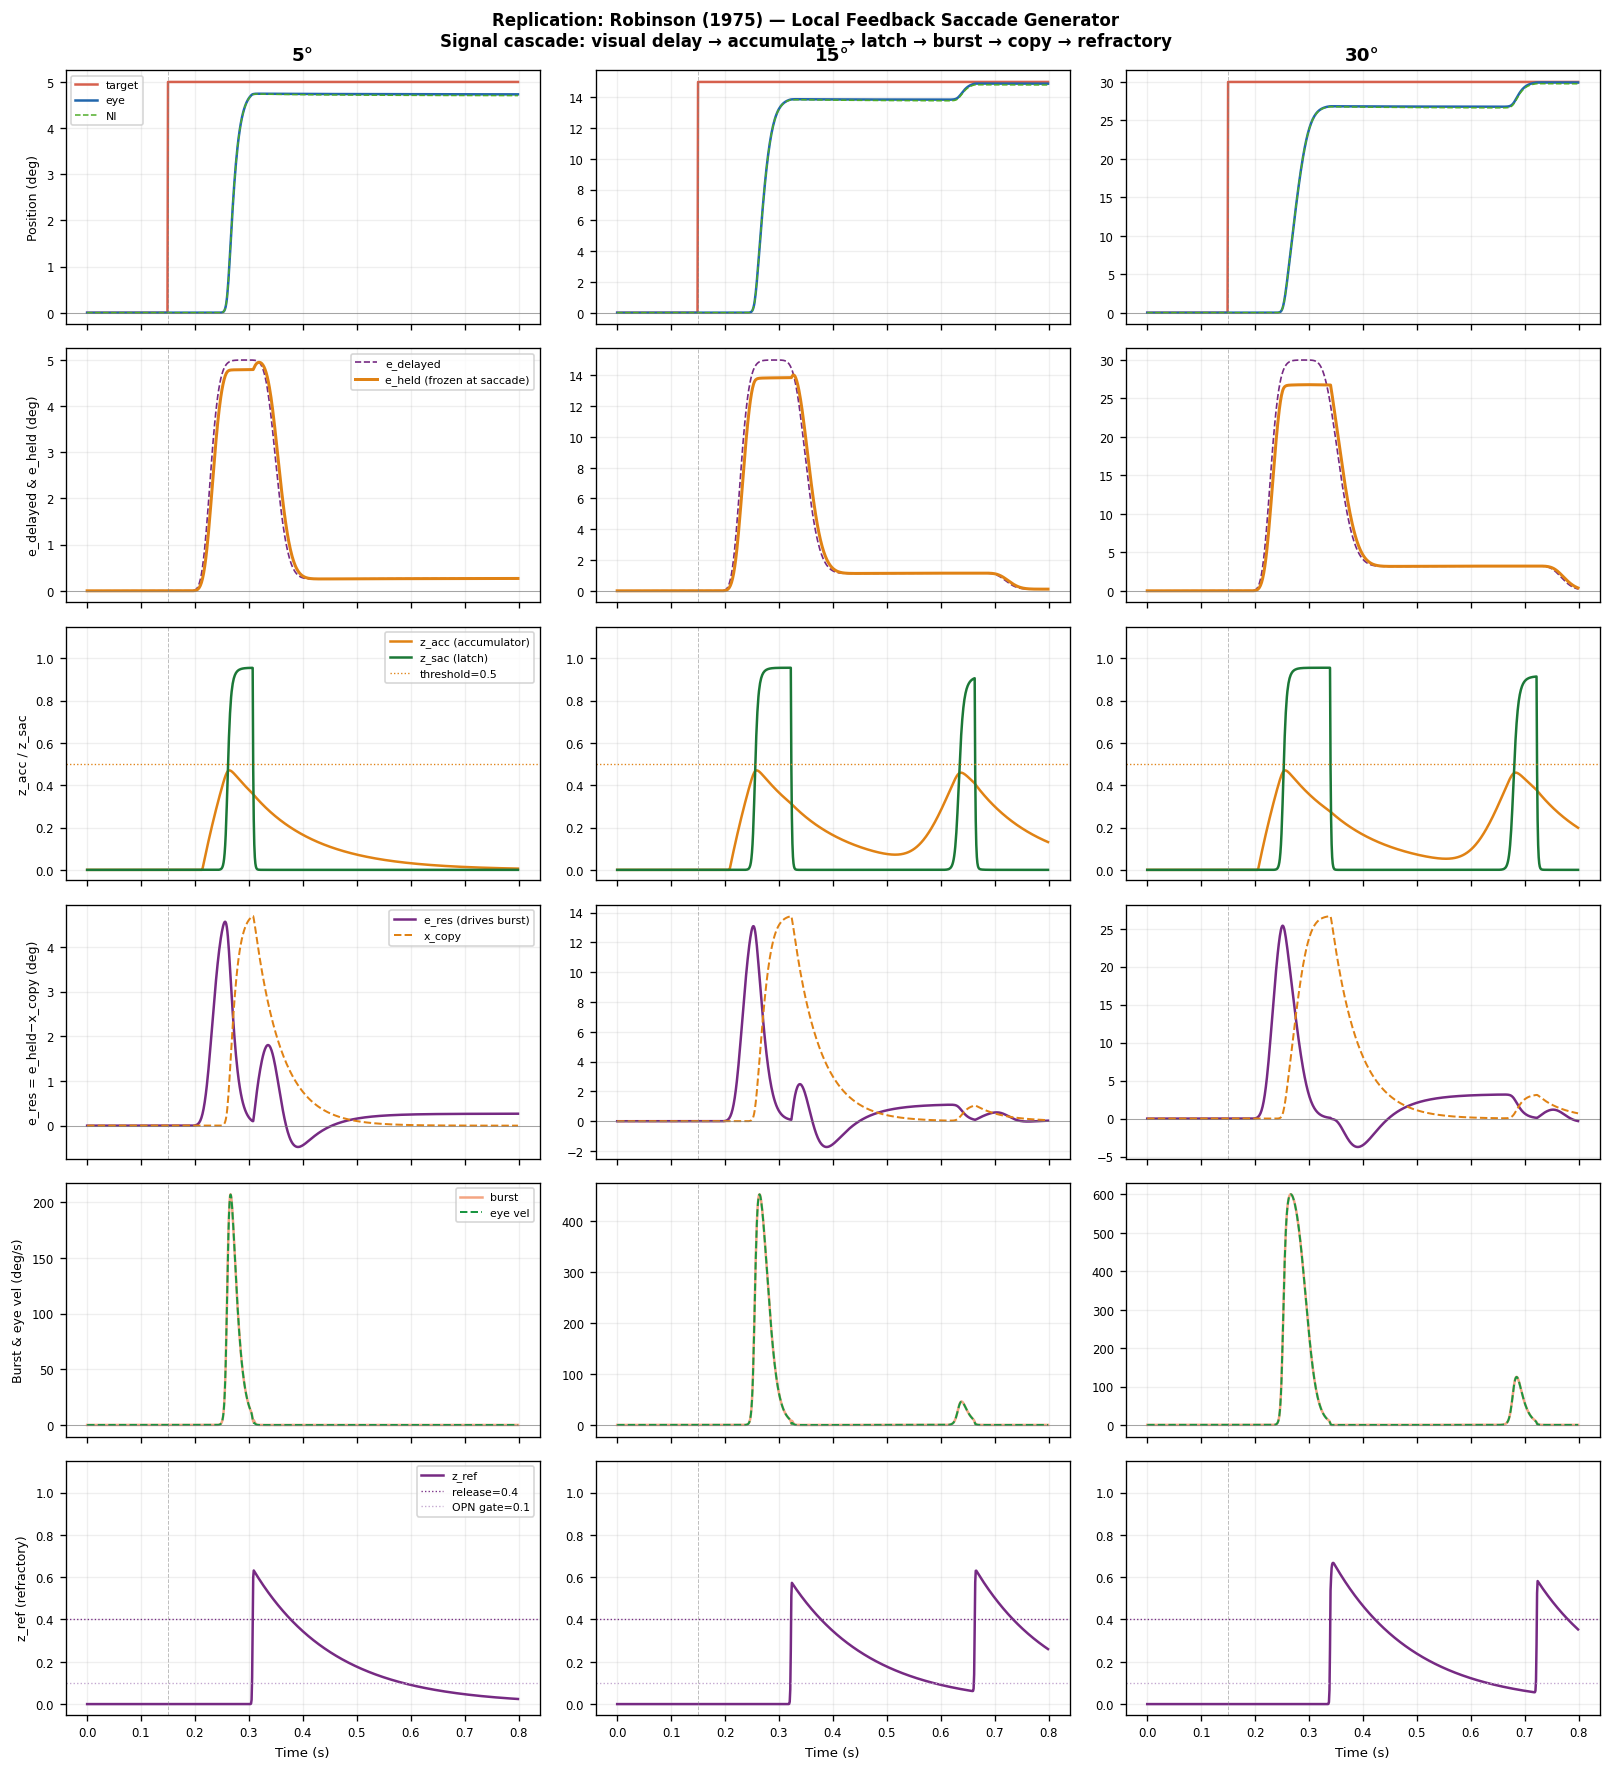

In [ ]:
n_rows, n_cols = 6, len(CASCADE_AMPS)
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(4.5*n_cols, 2.5*n_rows),
                          sharex=True)
fig.suptitle('Replication: Robinson (1975) — Local Feedback Saccade Generator\n'
             'Signal cascade: visual delay → accumulate → latch → burst → copy → refractory',
             fontsize=10, fontweight='bold')

row_labels = [
    'Position (deg)',
    'e_delayed & e_held (deg)',
    'z_acc / z_sac',
    'e_res = e_held−x_copy (deg)',
    'Burst & eye vel (deg/s)',
    'z_ref (refractory)',
]
for r, lbl in enumerate(row_labels):
    axes[r, 0].set_ylabel(lbl, fontsize=7.5)

for ci, amp in enumerate(CASCADE_AMPS):
    d = cascade_data[amp]
    axes[0, ci].set_title(f'{amp:.0f}°', fontsize=11, fontweight='bold')

    def vl(ax):
        ax.axvline(TJUMP_C, color='gray', lw=0.6, ls='--', alpha=0.5)

    # Row 0: position
    axes[0, ci].plot(t_c_np, d['tgt_yaw'], color=_C['target'], lw=1.5, label='target')
    axes[0, ci].plot(t_c_np, d['eye_pos'], color=_C['eye'],    lw=1.5, label='eye')
    axes[0, ci].plot(t_c_np, d['x_ni'][:, 0] if d['x_ni'].ndim==2 else d['x_ni'],
                     color=_C['ni'], lw=0.9, ls='--', label='NI')
    vl(axes[0, ci]); ax_fmt(axes[0, ci])
    if ci == 0: axes[0, ci].legend(fontsize=6.5)

    # Row 1: cascade output + sample-and-hold
    axes[1, ci].plot(t_c_np, d['e_pd'][:, 0] if d['e_pd'].ndim==2 else d['e_pd'],
                     color=_C['error'], lw=1.0, ls='--', label='e_delayed')
    axes[1, ci].plot(t_c_np, d['e_held'][:, 0] if d['e_held'].ndim==2 else d['e_held'],
                     color=_C['copy'],  lw=1.8, label='e_held (frozen at saccade)')
    vl(axes[1, ci]); ax_fmt(axes[1, ci])
    if ci == 0: axes[1, ci].legend(fontsize=6.5)

    # Row 2: trigger — z_acc + z_sac
    ax = axes[2, ci]
    ax.plot(t_c_np, d['z_acc'], color=_C['acc'],   lw=1.5, label='z_acc (accumulator)')
    ax.plot(t_c_np, d['z_sac'], color=_C['latch'], lw=1.5, label='z_sac (latch)')
    ax.axhline(THETA.brain.threshold_acc, color=_C['acc'], lw=0.8, ls=':',
               label=f'threshold={THETA.brain.threshold_acc:.1f}')
    ax.set_ylim(-0.05, 1.15)
    vl(ax); ax.grid(True, alpha=0.2); ax.tick_params(labelsize=7)
    if ci == 0: ax.legend(fontsize=6.5)

    # Row 3: ballistic residual e_res and x_copy
    e_res_plot = d['e_res'][:, 0] if hasattr(d['e_res'], 'ndim') and d['e_res'].ndim==2 else d['e_res']
    x_copy_plot = d['x_copy'][:, 0] if hasattr(d['x_copy'], 'ndim') and d['x_copy'].ndim==2 else d['x_copy']
    axes[3, ci].plot(t_c_np, e_res_plot,  color=_C['error'], lw=1.5, label='e_res (drives burst)')
    axes[3, ci].plot(t_c_np, x_copy_plot, color=_C['copy'],  lw=1.2, ls='--', label='x_copy')
    vl(axes[3, ci]); ax_fmt(axes[3, ci])
    if ci == 0: axes[3, ci].legend(fontsize=6.5)

    # Row 4: burst + eye velocity
    axes[4, ci].plot(t_c_np, d['u_burst_h'], color=_C['burst'], lw=1.5, label='burst')
    axes[4, ci].plot(t_c_np, d['eye_vel'],   color=_C['vel'],   lw=1.2, ls='--', label='eye vel')
    vl(axes[4, ci]); ax_fmt(axes[4, ci])
    if ci == 0: axes[4, ci].legend(fontsize=6.5)

    # Row 5: refractory
    ax = axes[5, ci]
    ax.plot(t_c_np, d['z_ref'], color='#762a83', lw=1.5, label='z_ref')
    ax.axhline(THETA.brain.threshold_sac_release, color='#762a83', lw=0.8, ls=':',
               label=f'release={THETA.brain.threshold_sac_release:.1f}')
    ax.axhline(THETA.brain.threshold_ref, color='#c2a5cf', lw=0.8, ls=':',
               label=f'OPN gate={THETA.brain.threshold_ref:.1f}')
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlabel('Time (s)', fontsize=8)
    vl(ax); ax.grid(True, alpha=0.2); ax.tick_params(labelsize=7)
    if ci == 0: ax.legend(fontsize=6.5)

fig.tight_layout()
plt.show()

---
## 3. Oblique Saccades — Synchronized Components

### Van Gisbergen, Van Opstal & Tax (1987) — *J Neurophysiol* 57:1033–1054

**Key finding:** Oblique saccades (targets requiring simultaneous H and V movements) have synchronized H and V components — both start and end together, and the eye follows a roughly straight path in orbital space. The slower component (larger required displacement) does not simply run its own main sequence independently.

**In the Robinson local feedback model:** Both H and V share the same `z_sac` latch and `z_ref` refractory state. The burst for each axis is proportional to `e_res` in that axis — so the components are naturally coupled through the shared gate.

> *Place Fig. 2 from Van Gisbergen et al. 1987 (2D saccade trajectories) here.*

In [ ]:
# ── Oblique saccade sequence ───────────────────────────────────────────────────
TEND_OBL  = 3.5
t_obl     = jnp.arange(0.0, TEND_OBL, DT)
T_obl     = len(t_obl)
t_obl_np  = np.array(t_obl)

# Sequence of 5 oblique targets covering all quadrants
jumps_obl = [
    (0.3,  15.0,   0.0),
    (0.9,  15.0,  10.0),
    (1.6,   0.0,  10.0),
    (2.2,   0.0,   0.0),
    (2.8, -10.0,   6.0),
]
pt3_obl, tgt_yaw_obl, tgt_pitch_obl = make_target(t_obl_np, jumps_obl, T_obl)

print('Running oblique saccade sequence...')
states_obl = simulate(THETA, t_obl, p_target_array=pt3_obl,
                      scene_present_array=jnp.ones(T_obl),
                      max_steps=int(TEND_OBL/DT)+500, return_states=True)
sg_obl = extract_sg(states_obl, THETA)
ep_obl = np.array(states_obl.plant)
print('Done.')

Running oblique saccade sequence...
Done.


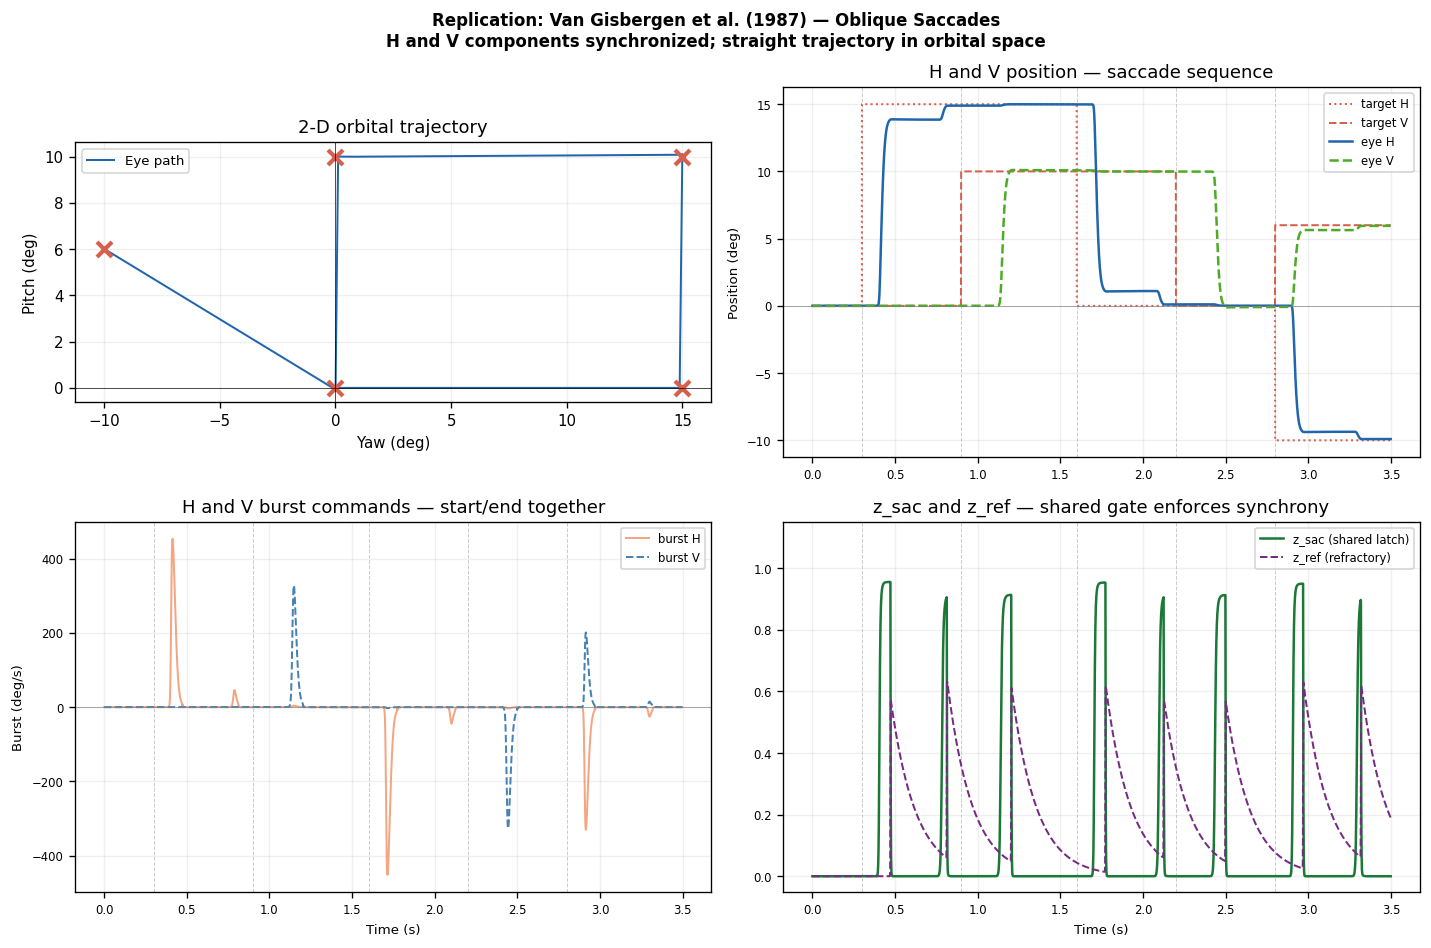

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Replication: Van Gisbergen et al. (1987) — Oblique Saccades\n'
             'H and V components synchronized; straight trajectory in orbital space',
             fontsize=10, fontweight='bold')

# ── 2D trajectory ─────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(ep_obl[:, 0], ep_obl[:, 1], color=_C['eye'], lw=1.2, label='Eye path')
for tj, y, p in jumps_obl:
    ax.plot(y, p, 'x', color=_C['target'], ms=9, markeredgewidth=2.5)
ax.set_xlabel('Yaw (deg)'); ax.set_ylabel('Pitch (deg)')
ax.set_title('2-D orbital trajectory')
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
ax.grid(True, alpha=0.2)
ax.legend(fontsize=8)

# ── H and V position over time ────────────────────────────────────────────────
ax = axes[0, 1]
for tj, _, _ in jumps_obl:
    ax.axvline(tj, color='gray', lw=0.6, ls='--', alpha=0.4)
ax.plot(t_obl_np, tgt_yaw_obl,   color=_C['target'], lw=1.2, ls=':', label='target H')
ax.plot(t_obl_np, tgt_pitch_obl, color=_C['target'], lw=1.2, ls='--', label='target V')
ax.plot(t_obl_np, ep_obl[:, 0],  color=_C['eye'],    lw=1.5, label='eye H')
ax.plot(t_obl_np, ep_obl[:, 1],  color='#4dac26',    lw=1.5, ls='--', label='eye V')
ax_fmt(ax, ylabel='Position (deg)')
ax.set_title('H and V position — saccade sequence')
ax.legend(fontsize=7)

# ── H and V burst — synchronized ─────────────────────────────────────────────
ax = axes[1, 0]
for tj, _, _ in jumps_obl:
    ax.axvline(tj, color='gray', lw=0.6, ls='--', alpha=0.4)
ax.plot(t_obl_np, sg_obl['u_burst'][:, 0], color=_C['burst'],    lw=1.2, label='burst H')
ax.plot(t_obl_np, sg_obl['u_burst'][:, 1], color='steelblue',    lw=1.2, ls='--', label='burst V')
ax_fmt(ax, ylabel='Burst (deg/s)', xlabel='Time (s)')
ax.set_title('H and V burst commands — start/end together')
ax.legend(fontsize=7)

# ── z_sac latch (shared for H and V) ─────────────────────────────────────────
ax = axes[1, 1]
for tj, _, _ in jumps_obl:
    ax.axvline(tj, color='gray', lw=0.6, ls='--', alpha=0.4)
ax.plot(t_obl_np, sg_obl['z_sac'], color=_C['latch'], lw=1.5, label='z_sac (shared latch)')
ax.plot(t_obl_np, sg_obl['z_ref'], color='#762a83',   lw=1.2, ls='--', label='z_ref (refractory)')
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.2); ax.tick_params(labelsize=7)
ax.set_xlabel('Time (s)', fontsize=8)
ax.set_title('z_sac and z_ref — shared gate enforces synchrony')
ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

### Comparison with Van Gisbergen et al. 1987

| Quantity | Van Gisbergen et al. 1987 | Model |
|----------|---------------------------|-------|
| H and V start simultaneously? | Yes | |
| H and V end simultaneously? | Yes | |
| Orbital trajectory straight? | Approximately | |
| Synchronization mechanism | Shared OPN gate | Shared z_sac latch |

---
## 4. Refractory Period

**Key finding (Becker & Jürgens 1979):** After a saccade, there is a minimum intersaccadic interval (~150–200 ms) during which a new saccade cannot be triggered — the **refractory period**. This corresponds to the decay of z_ref below the OPN gate threshold.

**Double-step paradigm:** Target jumps to A, then immediately to A+B. If the second jump occurs before the saccade to A has completed, the system must either combine them into one saccade or execute two sequential saccades with a refractory gap.

In [ ]:
# ── Refractory period: rapid sequential target steps ──────────────────────────
# Target steps at t=0.15, then again at t=0.15 + ISI for various ISIs.
# If ISI < refractory period, the second saccade is delayed.

TEND_R  = 1.2
TJUMP1  = 0.15
AMP1    = 10.0   # first step
AMP2    = 10.0   # second step (same direction — staircase)
ISIs    = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]   # seconds between steps

t_r    = jnp.arange(0.0, TEND_R, DT)
T_r    = len(t_r)
t_r_np = np.array(t_r)

print('Running refractory period simulations...')
ref_data = {}
for isi in ISIs:
    tjump2 = TJUMP1 + isi
    pt3_r, tgt_y, _ = make_target(t_r_np,
        [(TJUMP1, AMP1, 0.0), (tjump2, AMP1+AMP2, 0.0)], T_r)
    states_r = simulate(THETA, t_r, p_target_array=pt3_r,
                        scene_present_array=jnp.ones(T_r),
                        max_steps=int(TEND_R/DT)+200, return_states=True)
    sg_r = extract_sg(states_r, THETA)
    ep_r = np.array(states_r.plant)
    ref_data[isi] = dict(tgt_yaw=tgt_y, eye_pos=ep_r[:, 0],
                         z_sac=sg_r['z_sac'], z_ref=sg_r['z_ref'],
                         tjump2=tjump2)
print('Done.')

Running refractory period simulations...
Done.


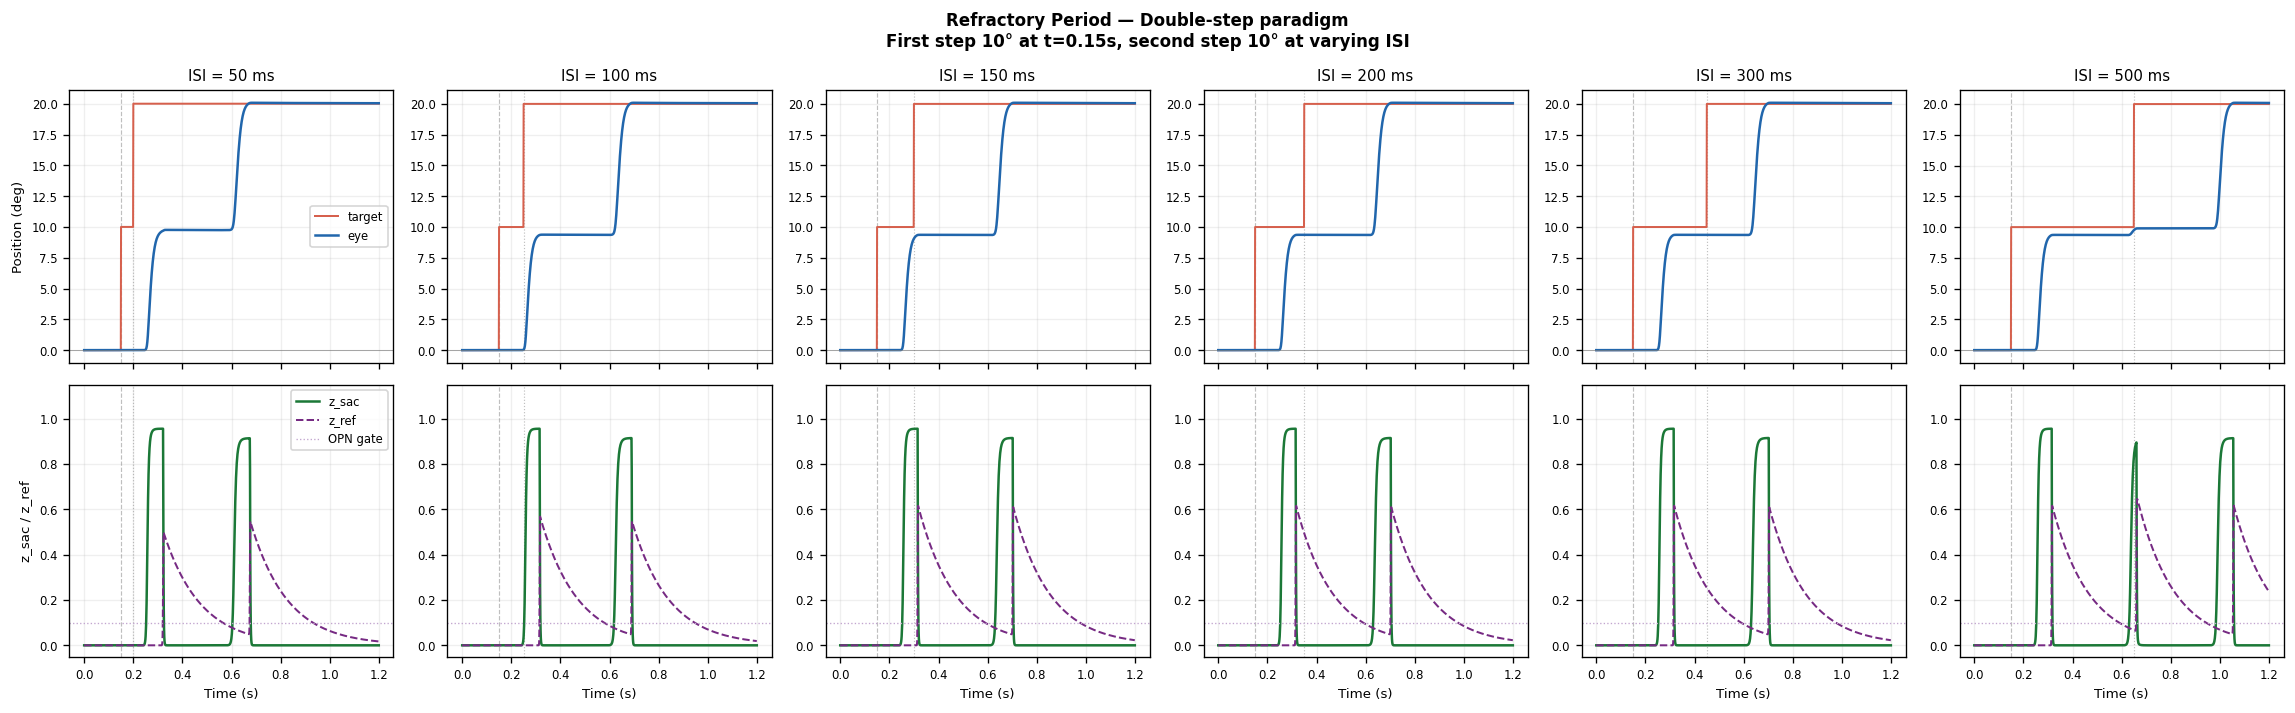

In [ ]:
n = len(ISIs)
fig, axes = plt.subplots(2, n, figsize=(3.2*n, 6), sharex=True)
fig.suptitle(f'Refractory Period — Double-step paradigm\n'
             f'First step {AMP1:.0f}° at t={TJUMP1}s, second step {AMP2:.0f}° at varying ISI',
             fontsize=10, fontweight='bold')

axes[0, 0].set_ylabel('Position (deg)', fontsize=8)
axes[1, 0].set_ylabel('z_sac / z_ref', fontsize=8)

for ci, isi in enumerate(ISIs):
    d = ref_data[isi]
    axes[0, ci].set_title(f'ISI = {isi*1000:.0f} ms', fontsize=9)

    axes[0, ci].axvline(TJUMP1,    color='gray', lw=0.7, ls='--', alpha=0.5)
    axes[0, ci].axvline(d['tjump2'], color='gray', lw=0.7, ls=':', alpha=0.5)
    axes[0, ci].plot(t_r_np, d['tgt_yaw'], color=_C['target'], lw=1.2, label='target')
    axes[0, ci].plot(t_r_np, d['eye_pos'], color=_C['eye'],    lw=1.5, label='eye')
    ax_fmt(axes[0, ci])
    if ci == 0: axes[0, ci].legend(fontsize=7)

    axes[1, ci].axvline(TJUMP1,    color='gray', lw=0.7, ls='--', alpha=0.5)
    axes[1, ci].axvline(d['tjump2'], color='gray', lw=0.7, ls=':', alpha=0.5)
    axes[1, ci].plot(t_r_np, d['z_sac'], color=_C['latch'], lw=1.5, label='z_sac')
    axes[1, ci].plot(t_r_np, d['z_ref'], color='#762a83',   lw=1.2, ls='--', label='z_ref')
    axes[1, ci].axhline(THETA.brain.threshold_ref, color='#c2a5cf', lw=0.8, ls=':',
                        label=f'OPN gate')
    axes[1, ci].set_ylim(-0.05, 1.15)
    axes[1, ci].set_xlabel('Time (s)', fontsize=8)
    axes[1, ci].grid(True, alpha=0.2); axes[1, ci].tick_params(labelsize=7)
    if ci == 0: axes[1, ci].legend(fontsize=7)

fig.tight_layout()
plt.show()

---
## Summary

| Property | Paper reference | Model parameter |
|----------|----------------|----------------|
| Peak velocity saturation (~700 deg/s) | Bahill et al. 1975 | `g_burst` |
| Half-saturation amplitude (~7°) | Bahill et al. 1975 | `k_sac` |
| Duration-amplitude linearity | Bahill et al. 1975 | `tau_p`, `k_sac` |
| Local feedback closure | Robinson 1975 | `x_copy` integrates burst |
| Oblique synchrony | Van Gisbergen 1987 | Shared `z_sac` latch |
| Refractory period (~150–200 ms) | Becker & Jürgens 1979 | `alpha_reset`, `threshold_ref` |

### Parameter sensitivity

| Parameter | Effect |
|-----------|--------|
| `g_burst` ↑ | Higher peak velocity; faster saccades |
| `k_sac` ↑ | Slower saturation; peak velocity rises more linearly with amplitude |
| `e_sat_sac` ↓ | Earlier saturation of burst; limits max velocity for large saccades |
| `tau_p` ↑ | Slower plant; longer duration, rounder velocity profile |
| `alpha_reset` ↑ | Faster z_ref decay → shorter refractory period |
| `threshold_acc` ↑ | Higher trigger threshold → longer latency, fewer microsaccades |